In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.5 MB/s eta 0:00:00


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 43.5/235.7 GB disk)


In [ ]:
# dataset: https://www.kaggle.com/datasets/tsunmm/icdar2003 
!unzip -q ICDAR2003.zip

In [26]:
import xml.etree.ElementTree as ET
import numpy as np
import os
from sklearn.model_selection import train_test_split
import shutil
import yaml
import json
import cv2
import matplotlib.pyplot as plt

In [5]:
# previous file
def extract_data_from_xml(path):

  bbox_list = []
  label_list = []
  size_list = []
  img_path_list = []

  # XML library
  tree = ET.parse(path + 'words.xml')
  root = tree.getroot()

  for image in root:
    bbox_image = []
    label_image = []

    # get 'taggedRectangle' for label_list and bbox_list
    for bbs in image.findall('taggedRectangles'):
        for bb_infor in bbs:
          # empty
          if len(bb_infor) == 0:
            continue

          # UPDATE: check non-number and non-alphabet
          if not bb_infor[0].text.isalnum():
            continue

          # UPDATE: fix data error
          if "é" in bb_infor[0].text.lower() or "ñ" in bb_infor[0].text.lower():
            continue

          # get bbox and label
          bb = [
              float(bb_infor.attrib['x']),
              float(bb_infor.attrib['y']),
              float(bb_infor.attrib['width']),
              float(bb_infor.attrib['height']),
          ]
          bb_label = bb_infor[0].text.lower()


          bbox_image.append(bb)
          label_image.append(bb_label)

    # get path and size
    img_name = image[0].text
    img_path = os.path.join(path, img_name)
    img_size = (int(image[1].attrib['x']), int(image[1].attrib['y']))

    # store
    img_path_list.append(img_path)
    size_list.append(img_size)
    bbox_list.append(bbox_image)
    label_list.append(label_image)

  return img_path_list, size_list, bbox_list, label_list

In [8]:
DATA_PATH = './data/SceneTrialTrain/'
print(f'Image path example: {extract_data_from_xml(DATA_PATH)[0][:2]}')
print(f'Image resolution example: {extract_data_from_xml(DATA_PATH)[1][:2]}')
print(f'Bounding boxes example: {extract_data_from_xml(DATA_PATH)[2][0][:2]}')
print(f'Image resolution example: {extract_data_from_xml(DATA_PATH)[3][0][:2]}')

Image path example: ['./data/SceneTrialTrain/apanar_06.08.2002/IMG_1261.JPG', './data/SceneTrialTrain/apanar_06.08.2002/IMG_1263.JPG']
Image resolution example: [(1600, 1200), (1600, 1200)]
Bounding boxes example: [[174.0, 392.0, 274.0, 195.0], [512.0, 391.0, 679.0, 183.0]]
Image resolution example: ['self', 'adhesive']


In [11]:
img_path_list, size_list, bbox_list, label_list = extract_data_from_xml(DATA_PATH)

# get an example in raw data
bbox_example = bbox_list[0][0]
size_example = size_list[0]
print(bbox_example)
print(size_example)

[174.0, 392.0, 274.0, 195.0]
(1600, 1200)


In [12]:
def convert_to_YOLO_format(bbox_list, size_list, img_path_list, class_label=0):
  labels = []
  for bbox_list_per_img, size_per_img, path_per_img in zip(bbox_list, size_list, img_path_list):
    labels_img = []

    width_img, height_img = size_per_img
    for bbox_sample in bbox_list_per_img:
      x, y, w, h = bbox_sample

      # top-left format to center
      x = (x + w/2)/width_img
      y = (y + h/2)/height_img
      w = w / width_img
      h = h / height_img

      label = f"{class_label} {x} {y} {w} {h}"
      labels_img.append(label)

    # save results
    labels.append((path_per_img, labels_img))

  return labels

In [17]:
data = convert_to_YOLO_format(bbox_list, size_list, img_path_list)
print(len(data))
data[0]

250


('./data/SceneTrialTrain/apanar_06.08.2002/IMG_1261.JPG',
 ['0 0.194375 0.40791666666666665 0.17125 0.1625',
  '0 0.5321875 0.40208333333333335 0.424375 0.1525',
  '0 0.309375 0.5825 0.38875 0.145',
  '0 0.67875 0.5770833333333333 0.27875 0.15583333333333332',
  '0 0.0746875 0.04125 0.059375 0.0725',
  '0 0.2159375 0.03833333333333333 0.123125 0.07333333333333333',
  '0 0.5309375 0.03375 0.071875 0.0675',
  '0 0.19625 0.7645833333333333 0.1425 0.11583333333333333',
  '0 0.3471875 0.7770833333333333 0.103125 0.09083333333333334',
  '0 0.4496875 0.7758333333333334 0.044375 0.08833333333333333',
  '0 0.571875 0.7620833333333333 0.13625 0.1175'])

In [19]:
seed = 0
test_ratio = 0.125
val_ratio = 0.2

train_data, val_data = train_test_split(
    data,
    test_size=val_ratio,
    random_state=seed,
    shuffle=True
)

train_data, test_data = train_test_split(
    train_data,
    test_size=test_ratio,
    random_state=seed,
    shuffle=True
)

len(train_data), len(val_data), len(test_data)

(175, 50, 25)

In [20]:
def create_yolo_file(path, data):
  # create train/val/test file
  os.makedirs(path, exist_ok=True)

  # create images and labels
  os.makedirs(os.path.join(path, 'images'), exist_ok=True)
  os.makedirs(os.path.join(path, 'labels'), exist_ok=True)

  for sample in data:
    # copy from raw data to YOLO format data
    img_path = sample[0]
    shutil.copy(img_path, os.path.join(path, 'images'))

    # get filename
    name = os.path.basename(img_path)
    name = os.path.splitext(name)[0]

    # write *txt file
    label_file = os.path.join(path, 'labels', f'{name}.txt')
    with open(label_file, 'w') as file:
      for label_text in sample[1]:
        file.write(label_text + '\n')

In [22]:
yolo_path = './data_YOLO_format/'
os.makedirs(yolo_path, exist_ok=True)

train_path = os.path.join(yolo_path, './train/')
valid_path = os.path.join(yolo_path, './valid/')
test_path = os.path.join(yolo_path, './test/')


create_yolo_file(train_path, train_data)
create_yolo_file(valid_path, val_data)
create_yolo_file(test_path, test_data)

In [23]:
yaml_content = {
    'nc': 1,
    'names': ['text'],
    'path': './data_YOLO_format',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
}

with open('./data_YOLO_format/data.yaml', 'w') as file:
  yaml.dump(yaml_content, file)

In [24]:
model = ultralytics.YOLO('yolo11m.pt')

train = model.train(
    data = './data_YOLO_format/data.yaml',
    epochs = 100,
    imgsz = 640,    # tốt nhất cho YOLO
    cache = True,   # đọc toàn bộ lên RAM
    patience=20,    # 20 epoch bắt đầu hành vi tương tự early stopping
    plots=True,     # vẽ đồ thị
)

Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data_YOLO_format/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=

In [25]:
best_model = '/content/runs/detect/train/weights/best.pt'
model = ultralytics.YOLO(best_model)
metrics = model.val()

Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1256.3±656.2 MB/s, size: 102.9 KB)
val: Scanning /content/data_YOLO_format/valid/labels.cache... 50 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 16.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.9it/s 1.4s
                   all         50        262      0.895      0.863      0.899      0.692
Speed: 3.7ms preprocess, 14.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val


In [27]:
def visualize_bbox(img_path, predictions, conf_thres=0.8, font=cv2.FONT_HERSHEY_SIMPLEX):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    for prediction in predictions:
        conf_score = prediction["confidence"]

        if conf_score < conf_thres:
            continue

        bbox = prediction["box"]
        xmin = int(bbox["x1"])
        ymin = int(bbox["y1"])
        xmax = int(bbox["x2"])
        ymax = int(bbox["y2"])

        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

        text = f"{conf_score:.2f}"
        (text_width, text_height), _ = cv2.getTextSize(text, font, 1, 2)

        cv2.rectangle(
            img,
            (xmin, ymin - text_height - 5),
            (xmin + text_width, ymin),
            (0, 255, 0),
            -1,
        )
        cv2.putText(img, text, (xmin, ymin - 5), font, 1, (0, 0, 0), 2)

    return img

In [57]:
# inference
inference_path = '/content/sample.JPG'
model = ultralytics.YOLO(best_model)
# results type: list[ultralytics.engine.results.Results]. Can convert to json and load like list.
results = model(inference_path, verbose=False)
predict = json.loads(results[0].to_json())
predict[0]

{'name': 'text',
 'class': 0,
 'confidence': 0.92009,
 'box': {'x1': 204.88458, 'y1': 206.83595, 'x2': 362.6911, 'y2': 248.81606}}

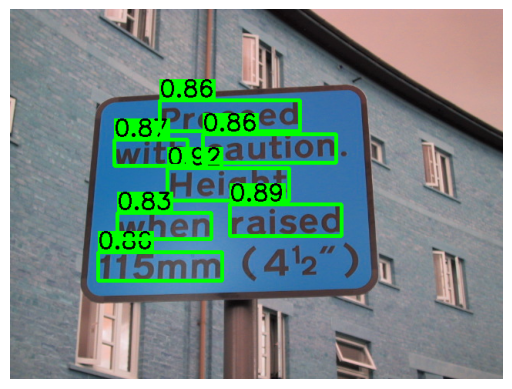

In [58]:
%matplotlib inline

# visualization sample
visualize_img = visualize_bbox(inference_path, predict, conf_thres=0.75)
plt.imshow(visualize_img)
plt.axis('off')
plt.show()


image 1/1 /root/.cache/huggingface/hub/models--huytqvn--text-detection-str-pipeline/snapshots/4cb1f80509aec9a7433516687e64b8c13f8eff64/sample.JPG: 480x640 8 texts, 15.6ms
Speed: 2.9ms preprocess, 15.6ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


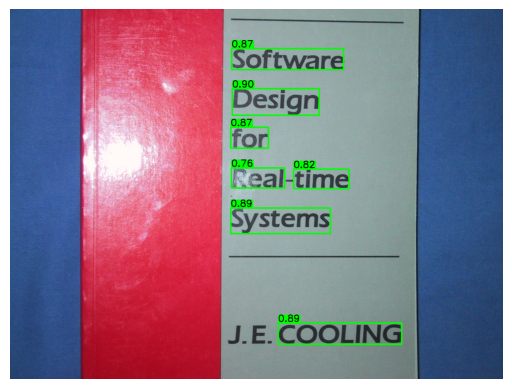

In [ ]:
# load model from hub.
# https://huggingface.co/huytqvn/text-detection-str-pipeline
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
import json
import cv2
import matplotlib.pyplot as plt


def visualize_bbox(img_path, predictions, conf_thres=0.8, font=cv2.FONT_HERSHEY_SIMPLEX):
    img = cv2.imread(img_path)

    for prediction in predictions:
        conf_score = prediction["confidence"]

        if conf_score < conf_thres:
            continue

        bbox = prediction["box"]
        xmin = int(bbox["x1"])
        ymin = int(bbox["y1"])
        xmax = int(bbox["x2"])
        ymax = int(bbox["y2"])

        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

        text = f"{conf_score:.2f}"
        (text_width, text_height), _ = cv2.getTextSize(text, font, 1, 2)

        cv2.rectangle(
            img,
            (xmin, ymin - text_height - 5),
            (xmin + text_width, ymin),
            (0, 255, 0),
            -1,
        )

        cv2.putText(img, text, (xmin, ymin - 5), font, 1, (0, 0, 0), 2)

    return img


# download model
model_path = hf_hub_download(
    repo_id="huytqvn/text-detection-str-pipeline",
    filename="best.pt"
)

# download sample image
sample_path = hf_hub_download(
    repo_id="huytqvn/text-detection-str-pipeline",
    filename="sample.JPG"
)

# load model
model = YOLO(model_path)

# inference
results = model(sample_path)

# convert prediction to python object
predict = json.loads(results[0].to_json())

# visualize
visualize_img = visualize_bbox(sample_path, predict, conf_thres=0.75)

# BGR -> RGB for matplotlib
visualize_img = cv2.cvtColor(visualize_img, cv2.COLOR_BGR2RGB)

plt.imshow(visualize_img)
plt.axis("off")
plt.show()